<a href="https://colab.research.google.com/github/ibonetc/IA_2026/blob/main/PCA_Wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Ejemplo de PCA: Vinos (UCI Wine)
Este cuaderno muestra cómo **PCA** puede:
- Reducir dimensionalidad (13 → *k* componentes)
- Mantener o mejorar rendimiento de un clasificador simple
- Acelerar el entrenamiento
- Facilitar la **visualización** en 2D

**Modelos comparados:**
1. Baseline: `StandardScaler + LogisticRegression` (13 features)
2. `StandardScaler + PCA(≥95% varianza) + LogisticRegression`
3. `StandardScaler + PCA(2 componentes) + LogisticRegression` (para visualización)


In [1]:

# Imports
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score,f1_score, precision_score, ConfusionMatrixDisplay

# Nota: No usamos seaborn. Cada gráfica es un plot independiente con matplotlib.


## Cargar datos

In [2]:
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

print(f"X shape: {X.shape}  | y shape: {y.shape}")
print("Clases:", target_names)
print("Rasgos:", feature_names)


X shape: (178, 13)  | y shape: (178,)
Clases: ['class_0' 'class_1' 'class_2']
Rasgos: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [3]:
len(feature_names)

13

## Dividir en entramiento y prueba

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


## ¿Cuántas PCs para ≥95% de varianza?

In [5]:
X_scaled = StandardScaler().fit_transform(X_train)

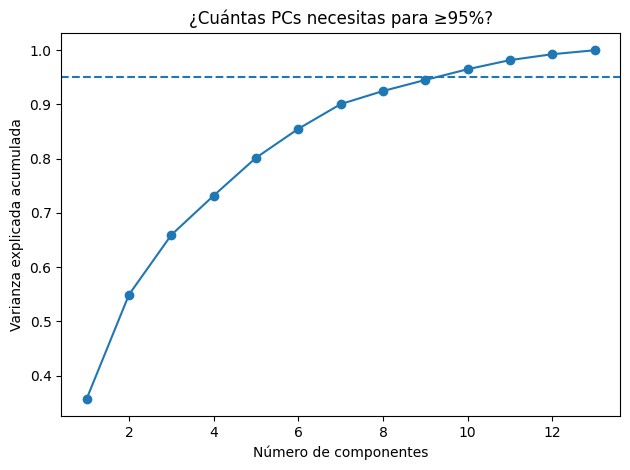

Componentes necesarios para ≥95% de varianza: 10


In [6]:
pca_full = PCA(n_components=X_train.shape[1], svd_solver="full").fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure()
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("¿Cuántas PCs necesitas para ≥95%?")
plt.tight_layout()
plt.show()
n95 = int(np.argmax(cum_var >= 0.95)) + 1
print(f"Componentes necesarios para ≥95% de varianza: {n95}")


## Función para entrenar con un pipeline y evaluar

In [7]:
def fit_and_eval(pipeline, name):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    recall= recall_score(y_test, y_pred, average='macro')
    f1= f1_score(y_test, y_pred, average='macro')
    precision= precision_score(y_test, y_pred, average='macro')
    return {
        "Model": name,
        "Accuracy": acc,
        "Recall": recall,
        "F1": f1,
        "Precision": precision,
        "y_pred": y_pred,
        "pipeline": pipeline
    }


# Regresión Logística sin normalizar

In [8]:
baseline = Pipeline([
    ("clf", LogisticRegression(max_iter=2000))
])
res_baseline = fit_and_eval(baseline, "feature_All")

print("Accuracy:\t", res_baseline["Accuracy"])
print("Recall:\t\t", res_baseline["Recall"])
print("F1:\t\t", res_baseline["F1"])
print("Precision:\t", res_baseline["Precision"])

Accuracy:	 0.9629629629629629
Recall:		 0.9555555555555556
F1:		 0.961038961038961
Precision:	 0.9710144927536232


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Pipeline con Escalado y Regresión logística

In [9]:
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])
res_baseline = fit_and_eval(baseline, "feature_All")

print("Accuracy:\t", res_baseline["Accuracy"])
print("Recall:\t\t", res_baseline["Recall"])
print("F1:\t\t", res_baseline["F1"])
print("Precision:\t", res_baseline["Precision"])


Accuracy:	 0.9814814814814815
Recall:		 0.9841269841269842
F1:		 0.9828609096901779
Precision:	 0.9824561403508771



## PCA reteniendo ≥95% de varianza + LogisticRegression

In [10]:
pca95 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("clf", LogisticRegression(max_iter=2000))
])
res_pca95 = fit_and_eval(pca95, "PCA (≥95% var) + LR")
print("Componentes retenidos:", res_pca95["pipeline"]["pca"].n_components_)
print("Accuracy:\t", res_pca95["Accuracy"])
print("Recall:\t\t", res_pca95["Recall"])
print("F1:\t\t", res_pca95["F1"])
print("Precision:\t", res_pca95["Precision"])


Componentes retenidos: 10
Accuracy:	 0.9814814814814815
Recall:		 0.9841269841269842
F1:		 0.9828609096901779
Precision:	 0.9824561403508771


# PCA con 2 componentes (para visualización) + LogisticRegression

In [11]:
pca2 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, svd_solver="full")),
    ("clf", LogisticRegression(max_iter=2000))
])
res_pca2 = fit_and_eval(pca2, "PCA (2 comps) + LR")
print("Componentes retenidos:", res_pca2["pipeline"]["pca"].n_components_)
print("Accuracy:\t", res_pca2["Accuracy"])
print("Recall:\t\t", res_pca2["Recall"])
print("F1:\t\t", res_pca2["F1"])
print("Precision:\t", res_pca2["Precision"])

Componentes retenidos: 2
Accuracy:	 0.9444444444444444
Recall:		 0.947089947089947
F1:		 0.9481727574750831
Precision:	 0.9500891265597148


In [12]:
rows = [
    {"Model": res_baseline["Model"], "n_components": len(feature_names), "Accuracy": res_baseline["Accuracy"], "Recall": res_baseline["Recall"], "Precision": res_baseline["Precision"]},
    {"Model": res_pca95["Model"], "n_components": res_pca95["pipeline"]["pca"].n_components_, "Accuracy": res_pca95["Accuracy"], "Recall": res_pca95["Recall"], "Precision": res_pca95["Precision"]},
    {"Model": res_pca2["Model"], "n_components": res_pca2["pipeline"]["pca"].n_components_, "Accuracy": res_pca2["Accuracy"],"Recall": res_pca2["Recall"], "Precision": res_pca2["Precision"]},
]
df_results = pd.DataFrame(rows)
df_results


,Model,n_components,Accuracy,Recall,Precision
0,feature_All,13,0.981481,0.984127,0.982456
1,PCA (≥95% var) + LR,10,0.981481,0.984127,0.982456
2,PCA (2 comps) + LR,2,0.944444,0.947090,0.950089


## Matrices de confusión

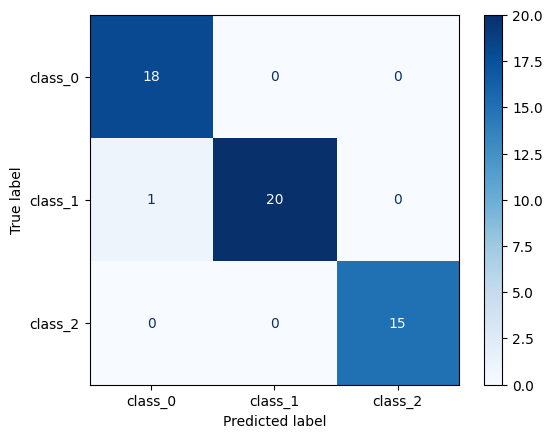

In [13]:
ConfusionMatrixDisplay.from_estimator(res_baseline["pipeline"], X_test, y_test, display_labels=target_names, cmap=plt.cm.Blues)

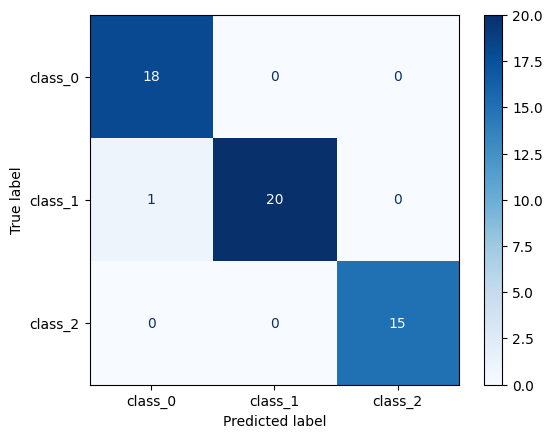

In [14]:
ConfusionMatrixDisplay.from_estimator(res_pca95["pipeline"], X_test, y_test, display_labels=target_names, cmap=plt.cm.Blues)

In [15]:
print(classification_report(y_test, res_baseline["y_pred"], target_names=target_names))

              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



In [16]:
print(classification_report(y_test, res_pca95["y_pred"], target_names=target_names))

              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



## Visualización 2D con las dos primeras PCs

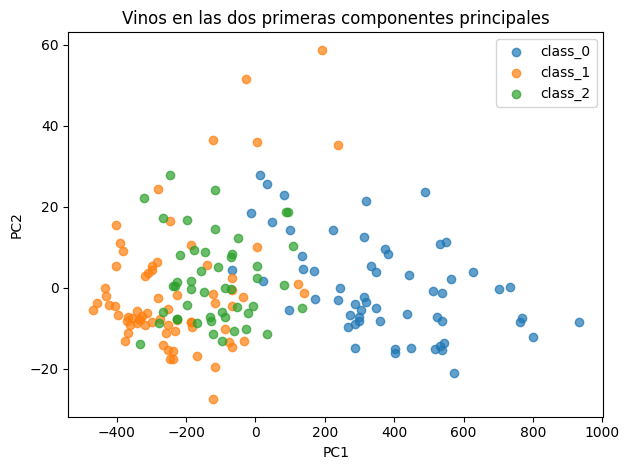

In [17]:
pca_2_full = PCA(n_components=2, svd_solver="full").fit(X)
X_pca2 = pca_2_full.transform(X)

plt.figure()
for cls in np.unique(y):
    idx = y == cls
    plt.scatter(X_pca2[idx, 0], X_pca2[idx, 1], label=target_names[cls], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Vinos en las dos primeras componentes principales")
plt.legend()
plt.tight_layout()
plt.show()

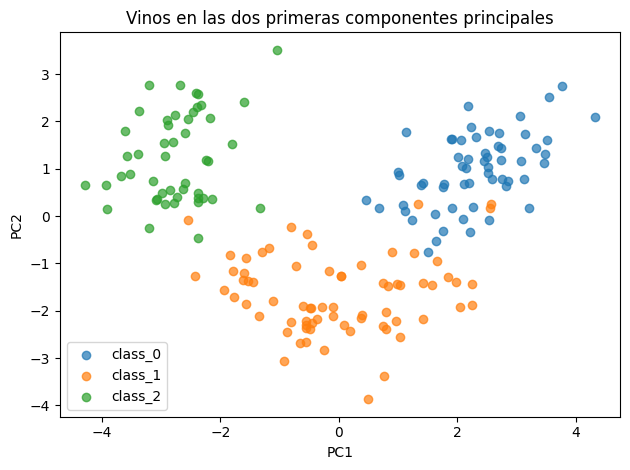

In [ ]:
scaler_full = StandardScaler().fit(X)
X_scaled = scaler_full.transform(X)
pca_2_full = PCA(n_components=2, svd_solver="full").fit(X_scaled)
X_pca2 = pca_2_full.transform(X_scaled)

plt.figure()
for cls in np.unique(y):
    idx = y == cls
    plt.scatter(X_pca2[idx, 0], X_pca2[idx, 1], label=target_names[cls], alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Vinos en las dos primeras componentes principales")
plt.legend()
plt.tight_layout()
plt.show()


## ¿Cuántas PCs para ≥95% de varianza?

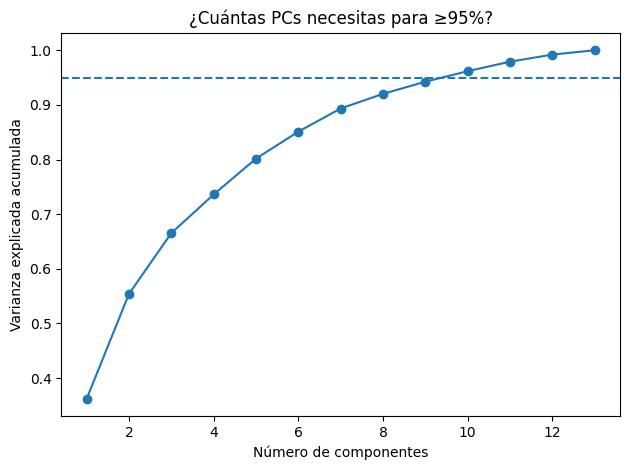

Componentes necesarios para ≥95% de varianza: 10


In [ ]:
pca_full = PCA(n_components=min(X.shape[1], X.shape[0]), svd_solver="full").fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure()
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("¿Cuántas PCs necesitas para ≥95%?")
plt.tight_layout()
plt.show()

n95 = int(np.argmax(cum_var >= 0.95)) + 1
print(f"Componentes necesarios para ≥95% de varianza: {n95}")
